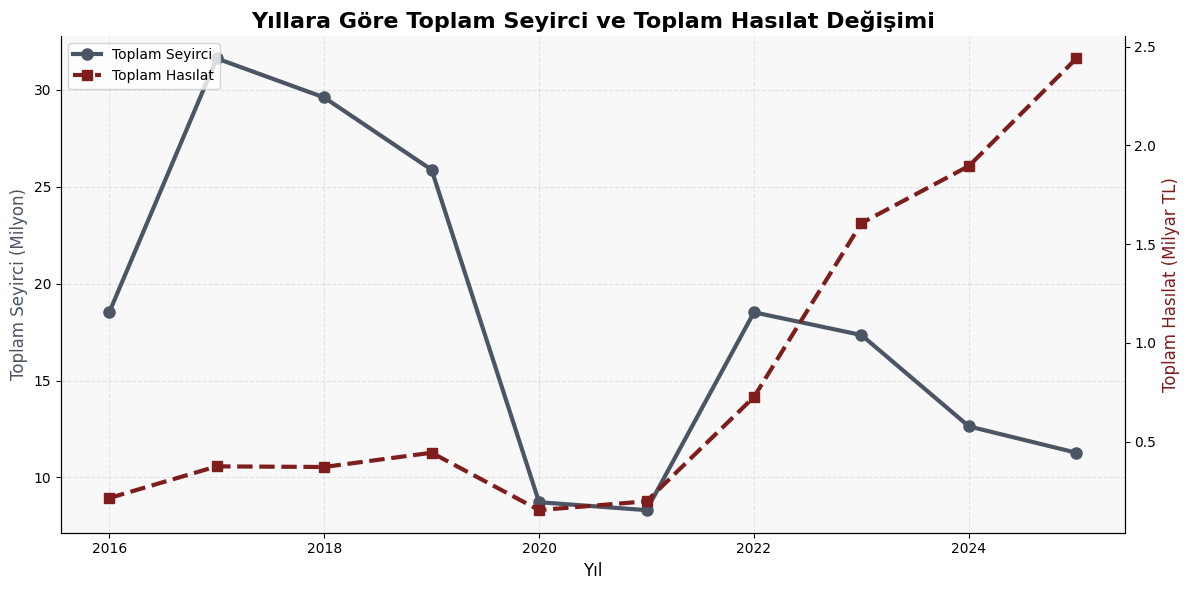

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(
    r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx"
)

# Yıllara göre toplamlar
yillik_veri = (
    df.groupby("vizyon_tarihi")
      .agg({
          "toplam_seyirci": "sum",
          "toplam_hasilat": "sum"
      })
      .reset_index()
      .sort_values("vizyon_tarihi")
)

# Ölçeklendirme
yillik_veri["seyirci_milyon"] = yillik_veri["toplam_seyirci"] / 1_000_000
yillik_veri["hasilat_milyar"] = yillik_veri["toplam_hasilat"] / 1_000_000_000

# Grafik boyutu
fig, ax1 = plt.subplots(figsize=(12, 6))

# Arka plan
fig.patch.set_facecolor("white")
ax1.set_facecolor("#f8f8f8")

# Seyirci çizgisi
ax1.plot(
    yillik_veri["vizyon_tarihi"],
    yillik_veri["seyirci_milyon"],
    marker="o",
    markersize=8,
    linewidth=3,
    color="#4B5563",   # Soft koyu gri
    label="Toplam Seyirci"
)

ax1.set_xlabel("Yıl", fontsize=12)
ax1.set_ylabel("Toplam Seyirci (Milyon)",
    fontsize=12,
    color="#4B5563"
)

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=False
)

# Grid
ax1.grid(True, linestyle="--", alpha=0.3)

# İkinci eksen
ax2 = ax1.twinx()

# Hasılat çizgisi
ax2.plot(
    yillik_veri["vizyon_tarihi"],
    yillik_veri["hasilat_milyar"],
    marker="s",
    markersize=7,
    linewidth=3,
    linestyle="--",
    color="#7F1D1D",   # Mat bordo
    label="Toplam Hasılat"
)
ax2.set_ylabel(
    "Toplam Hasılat (Milyar TL)",
    fontsize=12,
    color="#7F1D1D"
)

# Başlık
plt.title(
    "Yıllara Göre Toplam Seyirci ve Toplam Hasılat Değişimi",
    fontsize=16,
    fontweight="bold"
)

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
    frameon=True
)

# Grafik kenarlarını sadeleştir
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.savefig(
    "../images/yillik_seyirci_hasilat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

### Grafik Hakkında

Bu grafik, yıllara göre toplam seyirci sayısı ile toplam hasılat değişimini birlikte incelemek amacıyla oluşturulmuştur. Grafik sayesinde sinema sektöründeki izleyici eğilimleri ile ekonomik değişimler aynı anda analiz edilebilmektedir.

Çizgi grafik tercih edilmesinin temel nedeni, yıllar içerisindeki değişim trendini ve kırılma noktalarını daha net gösterebilmesidir. Özellikle 2020 yılında pandemi etkisiyle yaşanan ani düşüş ve sonrasında seyirci sayısı ile hasılat arasındaki ayrışma çizgi grafik ile daha anlaşılır hale gelmiştir.
### Grafik Yorumu
Grafik incelendiğinde 2017–2019 yılları arasında sinema sektörünün yüksek seyirci sayılarına ulaştığı görülmektedir. 2020 yılında ise COVID-19 pandemisinin etkisiyle hem toplam seyirci sayısında hem de toplam hasılatta ciddi bir düşüş yaşanmıştır.

2022 yılı sonrasında seyirci sayıları pandemi öncesi seviyelere ulaşamasa da toplam hasılatın hızla yükseldiği dikkat çekmektedir. Özellikle 2023–2025 döneminde seyirci sayısındaki düşüşe rağmen hasılatın artması, bilet fiyatlarındaki artış ve enflasyon etkisinin sinema gelirleri üzerinde belirleyici olduğunu göstermektedir.

Bu grafik, son yıllarda sinema sektöründe daha az seyirci ile daha yüksek gelir elde edilen yeni bir ekonomik yapının oluştuğunu ortaya koymaktadır.

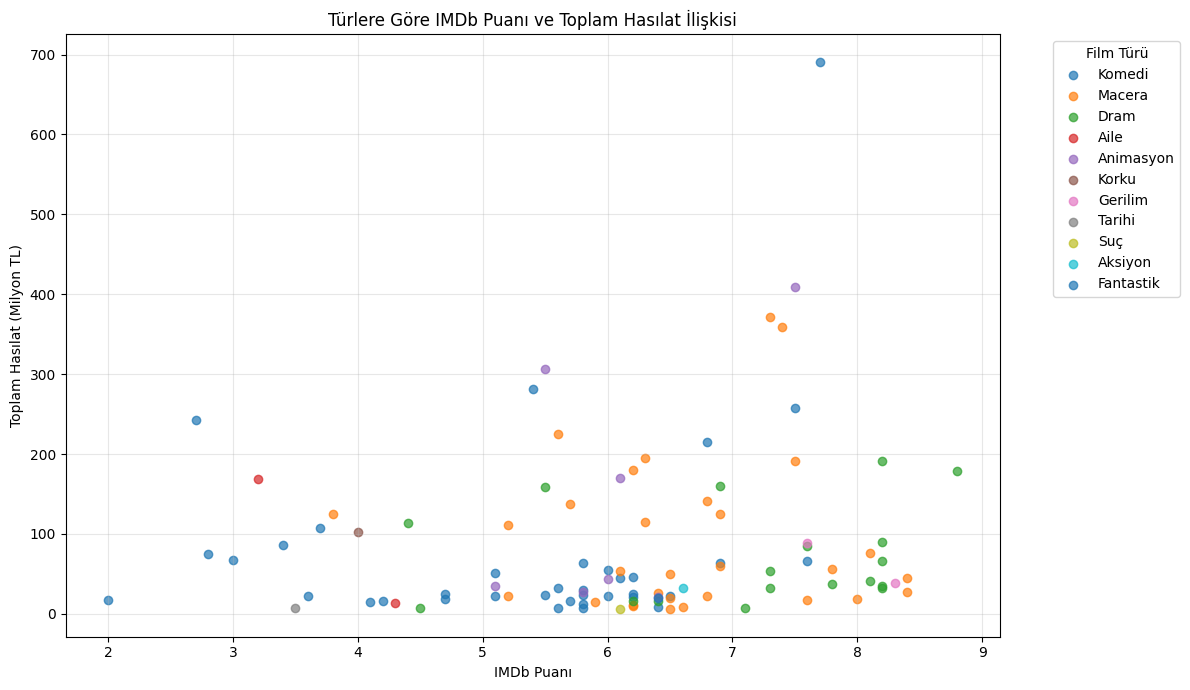

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx")

# Grafik boyutu
plt.figure(figsize=(12,7))

# Türleri al
ana_turler = df["ana_tur"].unique()

# Her tür için ayrı renk
for ana_tur in ana_turler:
    
    filtre = df[df["ana_tur"] == ana_tur]

    plt.scatter(
        filtre["imdb_puani"],
        filtre["toplam_hasilat"] / 1_000_000,
        alpha=0.7,
        label=ana_tur
    )

# Başlık
plt.title("Türlere Göre IMDb Puanı ve Toplam Hasılat İlişkisi")

# Eksenler
plt.xlabel("IMDb Puanı")
plt.ylabel("Toplam Hasılat (Milyon TL)")

# Grid
plt.grid(True, alpha=0.3)

# Legend
plt.legend(title="Film Türü", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Grafik Hakkında

Bu scatter plot grafik, IMDb puanı ile toplam hasılat arasındaki ilişkiyi film türlerine göre incelemek amacıyla oluşturulmuştur. Grafik üzerinde her nokta bir filmi temsil ederken, farklı renkler filmlerin türlerini göstermektedir.

Scatter plot tercih edilmesinin temel nedeni, iki sayısal değişken arasındaki ilişkiyi ve veri dağılımını en net şekilde gösterebilmesidir. Türlere göre renk ayrımı yapılması sayesinde yalnızca IMDb puanı ile hasılat ilişkisi değil, aynı zamanda hangi film türlerinin daha yüksek ticari başarı elde ettiği de analiz edilebilmektedir.

### Grafik Yorumu

Grafik incelendiğinde IMDb puanı ile toplam hasılat arasında tam doğrusal bir ilişki olmadığı görülmektedir. Yüksek IMDb puanına sahip bazı filmler düşük veya orta seviyede hasılat elde ederken, bazı filmler ise orta seviyede IMDb puanlarına rağmen oldukça yüksek hasılat değerlerine ulaşmıştır.

Özellikle macera, animasyon ve fantastik türündeki bazı filmlerin yüksek hasılat seviyelerine ulaştığı dikkat çekmektedir. Buna karşılık dram türündeki filmler genel olarak daha yüksek IMDb puanlarına sahip olsa da hasılat açısından daha dengeli bir dağılım göstermektedir.

Grafik genel olarak değerlendirildiğinde, film kalitesini temsil eden IMDb puanının ticari başarı üzerinde etkili olduğu görülse de tek belirleyici unsur olmadığı anlaşılmaktadır. Film türü, hedef kitle ve popülerlik gibi faktörlerin de toplam hasılat üzerinde önemli etkileri olduğu söylenebilir.


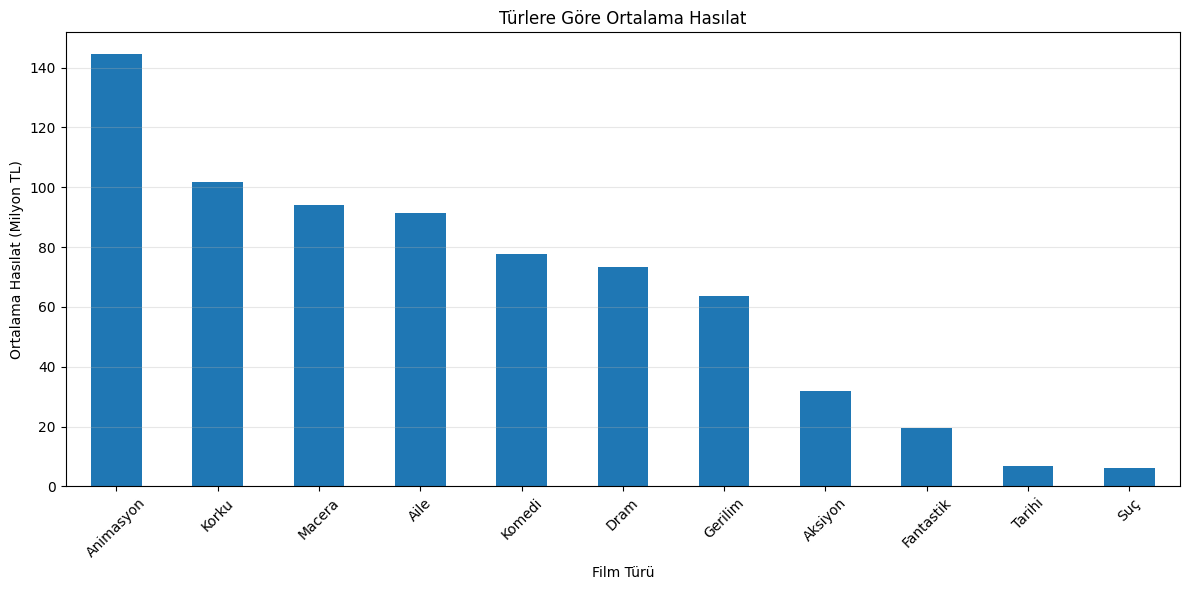

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_excel(r"C:\Users\Zeynep\OneDrive\Desktop\sinema-veri-analizi\sinema-veri-analizi\data\Son 10 yılın sinema filmleri.xlsx")

# Türlere göre ortalama hasılat
tur_hasilat = (
    df.groupby("ana_tur")["toplam_hasilat"]
      .mean()
      .sort_values(ascending=False)
)

# Milyon TL'ye çevir
tur_hasilat_milyon = tur_hasilat / 1_000_000

# Grafik
plt.figure(figsize=(12, 6))

tur_hasilat_milyon.plot(kind="bar")

plt.title("Türlere Göre Ortalama Hasılat")
plt.xlabel("Film Türü")
plt.ylabel("Ortalama Hasılat (Milyon TL)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()